# Tag Recommendation Experiment (RecSys 2018)

Notebook simple et modulaire pour reproduire une expérience inspirée de l'article **Semantic-based Tag Recommendation in Scientific Bookmarking Systems**.

- Import des données : **1 cellule**
- Une fonction par cellule
- Visualisations déplacées dans `src/visualization.py`
- Dernière cellule : compilation des résultats + visualisations comparatives

In [1]:
# Cellule 1 - Imports (meme stack que l'article)
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.data as data_module
import src.experiment as experiment_module
import src.visualization as visualization_module

importlib.reload(data_module)
importlib.reload(experiment_module)
importlib.reload(visualization_module)

load_simple_dataset = data_module.load_simple_dataset
keep_top_k_tags = data_module.keep_top_k_tags
preprocess_text_nltk = data_module.preprocess_text_nltk
text_length_stats = data_module.text_length_stats
prepare_train_test = experiment_module.prepare_train_test
run_all_models = experiment_module.run_all_models
plot_tag_distribution = visualization_module.plot_tag_distribution
plot_text_length_distributions = visualization_module.plot_text_length_distributions
plot_model_metrics = visualization_module.plot_model_metrics
plot_article_vs_current = visualization_module.plot_article_vs_current

pd.set_option("display.max_colwidth", 120)

I0000 00:00:1776293109.625685  839005 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776293109.625942  839005 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776293109.646821  839005 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776293110.263797  839005 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

In [ ]:
# Cellule 2 - Paramètres globaux
DATA_PATH = str(PROJECT_ROOT / "data" / "citeulike-a" / "raw-data.csv")
GLOVE_PATH = str(PROJECT_ROOT / "data" / "dolma_300_2024_1.2M.100_combined.txt")  # optionnel
METRICS_PATH = str(PROJECT_ROOT / "data" / "metrics_results.csv")

TOP_K_TAGS = 100
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [10]:
# Cellule 3 - Import des données (simple, en une cellule)
def import_data(csv_path: str, top_k_tags: int = 10):
    df = load_simple_dataset(csv_path)
    df = keep_top_k_tags(df, top_k=top_k_tags)
    df = preprocess_text_nltk(df)
    return text_length_stats(df)


df = import_data(DATA_PATH, TOP_K_TAGS)
df.head()

,title,abstract,tags,text,tag_list,processed_text,title_words,abstract_words,text_words,num_tags
0,The metabolic world of Escherichia coli is not small,"To elucidate the organizational and evolutionary principles of the metabolism of living organisms, recent studies ha...",dissertation|metabolism|network|metabolic_networks|metabolic|review|ecoli|small-world|scale_free|barabasi|meta|miran...,The metabolic world of Escherichia coli is not small. To elucidate the organizational and evolutionary principles of...,"[network, review, systems_biology, networks]",metabolic world escherichia coli small elucidate organizational evolutionary principle metabolism living organism re...,9,174,119,4
1,Reverse Engineering of Biological Complexity,"Advanced technologies and biology have extremely different physical implementations, but they are far more alike in ...",behaviors|control|controllability|key--systems_biology|modularity|coding|robustness_analysis|engineering|intro|desig...,Reverse Engineering of Biological Complexity. Advanced technologies and biology have extremely different physical im...,"[design, modeling, networks, network, review, complexity, biology, evolution, model, systems_biology]",reverse engineering biological complexity advanced technology biology extremely different physical implementation fa...,5,123,82,10
2,Exploring complex networks,"The study of networks pervades all of science, from neurobiology to statistical physics. {T}he most basic issues are...",scalefree|bistability|senior-project|complex-networks|socialnetanalyse|networks|networks_theory|network_dynamics|exa...,"Exploring complex networks. The study of networks pervades all of science, from neurobiology to statistical physics....","[networks, dynamics, statistics, social-networks, network, graph, structure, systems-biology, social_networks, syste...",exploring complex network study network pervades science neurobiology statistical physic basic issue structural one ...,3,99,63,13
3,Comparative assessment of large-scale data sets of protein-protein interactions.,Comprehensive protein protein interaction maps promise to reveal many aspects of the complex regulatory network unde...,false|features|pin|network_confidence|ppi|two-hybrid|binding|thesis|analysisy2h|networks|comparative_assessment|ppi-...,Comparative assessment of large-scale data sets of protein-protein interactions.. Comprehensive protein protein inte...,"[ppi, thesis, networks, systems_biology, network, interactions, yeast, statistics, bioinformatics, structure, protei...",comparative assessment large scale data set protein protein interaction comprehensive protein protein interaction ma...,9,61,50,14
4,Navigation in a small world,The small-world phenomenon â the principle that most of us are linked by short chains of acquaintances â was fir...,diktyology|complex-networks|filing-small-world-network|cybernetics|thesis|world|networks|exploratory_search|network|...,Navigation in a small world. The small-world phenomenon â the principle that most of us are linked by short chains...,"[thesis, networks, network, evaluation, theory, search, social_networks, algorithm, analysis, complexity, social, mo...",navigation small world small world phenomenon principle u linked short chain acquaintance first investigated questio...,5,103,60,12


In [4]:
# Cellule 4 - Fonction de résumé exploration
def summarize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    summary = {
        "num_documents": [len(df)],
        "num_unique_tags": [len({t for tags in df["tag_list"] for t in tags})],
        "avg_title_words": [df["title_words"].mean()],
        "avg_abstract_words": [df["abstract_words"].mean()],
        "avg_tags_per_doc": [df["num_tags"].mean()],
    }
    return pd.DataFrame(summary)


summarize_dataset(df)

,num_documents,num_unique_tags,avg_title_words,avg_abstract_words,avg_tags_per_doc
0,11135,100,8.74405,182.22308,4.032959


/home/victor/projet/projet_session/src/visualization.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")


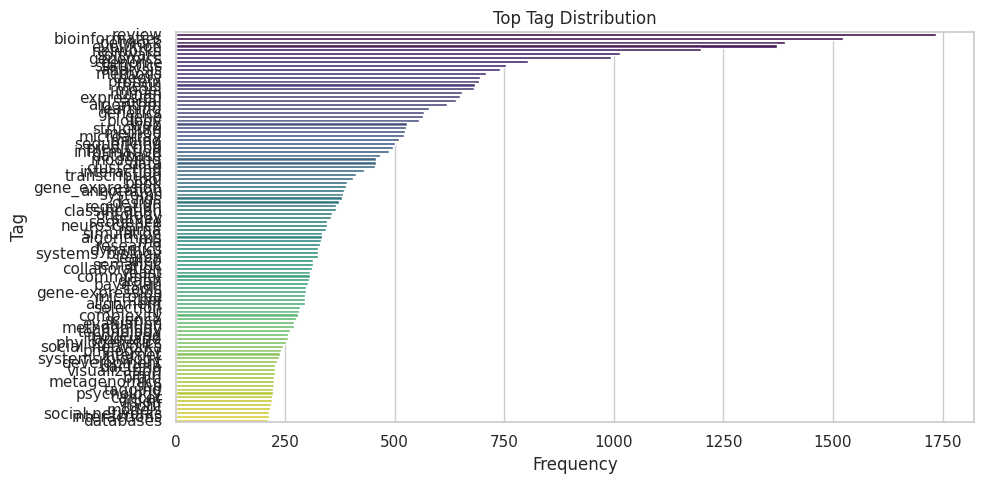

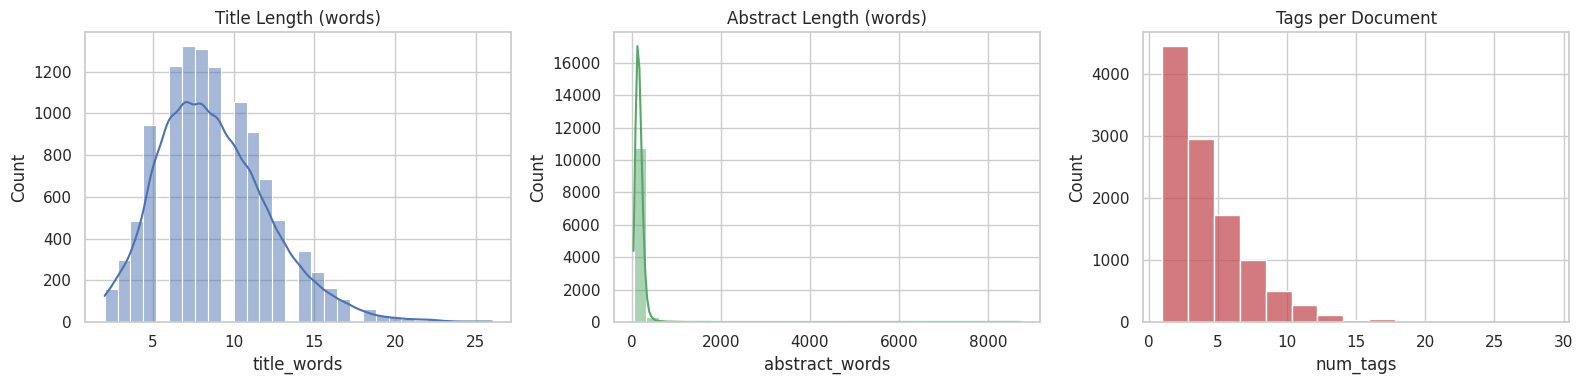

In [5]:
# Cellule 5 - Fonction visualisation EDA
def visualize_eda(df: pd.DataFrame):
    fig1 = plot_tag_distribution(df, top_n=TOP_K_TAGS)
    fig2 = plot_text_length_distributions(df)
    plt.show()
    return fig1, fig2


_ = visualize_eda(df)

In [6]:
# Cellule 6 - Préparation train/test
def make_splits(df: pd.DataFrame):
    return prepare_train_test(
        df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )


X_train, X_test, y_train, y_test, mlb = make_splits(df)
print("Train:", len(X_train), "Test:", len(X_test), "Labels:", len(mlb.classes_))

Train: 8908 Test: 2227 Labels: 100


In [7]:
# Cellule 7 - Entraînement de tous les modèles
def train_models(X_train, X_test, y_train, y_test, n_topics: int, glove_path: str):
    return run_all_models(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        n_topics=n_topics,
        glove_path=glove_path,
    )


metrics_df, predictions = train_models(
    X_train,
    X_test,
    y_train,
    y_test,
    n_topics=TOP_K_TAGS,
    glove_path=GLOVE_PATH,
)
metrics_df

E0000 00:00:1776293246.010651  839005 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776293246.092897  839005 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


,name,micro_recall,micro_precision,micro_f1
0,SVM,0.319560,0.654103,0.429358
1,Paragraph Vector,0.343476,0.437062,0.384659
2,NB,0.726926,0.229648,0.349031
3,LDA,0.086346,0.738004,0.154604
4,Bi-GRU+Att,0.231305,0.046506,0.077442


In [14]:
# Cellule 8 - Sauvegarde facultative des métriques
def save_metrics(metrics_df: pd.DataFrame, output_csv: str = PROJECT_ROOT / "output" / "metrics_results.csv"):
    metrics_df.to_csv(output_csv, index=False)
    return output_csv


save_metrics(metrics_df)

PosixPath('/home/victor/projet/projet_session/output/metrics_results.csv')

,name,micro_recall,micro_precision,micro_f1
0,SVM,0.319560,0.654103,0.429358
1,Paragraph Vector,0.343476,0.437062,0.384659
2,NB,0.726926,0.229648,0.349031
3,LDA,0.086346,0.738004,0.154604
4,Bi-GRU+Att,0.231305,0.046506,0.077442


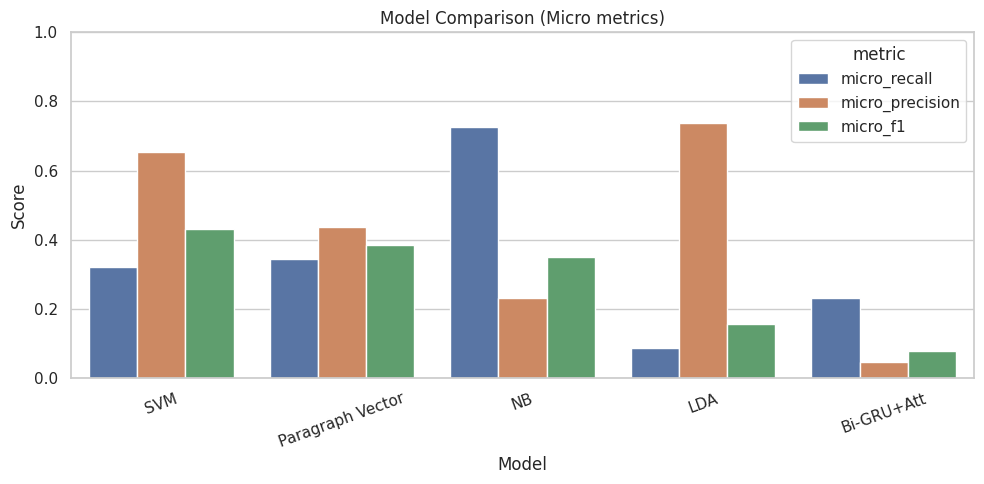

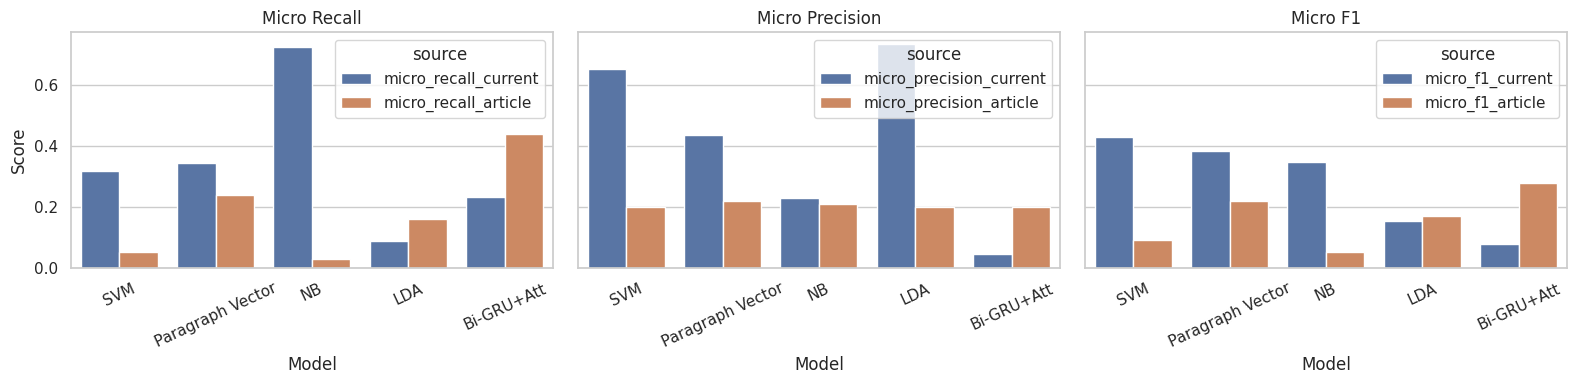

{'best_model': 'SVM', 'best_micro_f1': 0.42935807497925627}

In [15]:
# Cellule 9 (dernière) - Compilation + visualisations comparatives
def compile_and_compare(metrics_df: pd.DataFrame):
    display(metrics_df.sort_values("micro_f1", ascending=False).reset_index(drop=True))

    fig_models = plot_model_metrics(metrics_df)
    fig_article = plot_article_vs_current(metrics_df)
    plt.show()

    return {
        "best_model": metrics_df.sort_values("micro_f1", ascending=False).iloc[0]["name"],
        "best_micro_f1": float(metrics_df["micro_f1"].max()),
    }


summary = compile_and_compare(metrics_df)
summary